## Analysis of spatial factors corresponding to endothelial subpopulations

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import os
import sys

import warnings
warnings.filterwarnings("ignore")

### Load results

In [2]:
res_path = "/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tutorials/new_examples/human_breast_cancer_xenium"
adata = sc.read_h5ad(res_path + "/adata_inspire.h5ad")
basis_df = pd.read_csv(res_path + "/basis_df_inspire.csv", index_col=0)
adata.obsm["factors"] = np.array(adata.obs[["Proportion of spatial factor "+str(j+1) for j in range(50)]].values)

### Visualization of gene signatures

In [3]:
topic_id = 36

topic_profile = np.array(basis_df.iloc[topic_id,:].values)
order = np.argsort(-topic_profile)
print(basis_df.columns[order])

potential_marker = list(basis_df.columns[order[:50]])
marker_ours = []
for i in range(len(potential_marker)):
    id_1 = np.argsort(-basis_df[potential_marker[i]])[0]
    id_2 = np.argsort(-basis_df[potential_marker[i]])[1]
    val_1 = basis_df[potential_marker[i]][id_1]
    val_2 = basis_df[potential_marker[i]][id_2]
    if (id_1 == topic_id) & (val_1 >= (val_2*1.5)):
        marker_ours.append(potential_marker[i])
print(marker_ours)

Index(['KDR', 'BTNL9', 'CLEC14A', 'RAMP2', 'ESM1', 'CD93', 'CAV1', 'SOX17',
       'EDNRB', 'HOXD9',
       ...
       'TACSTD2', 'SFRP1', 'CYTIP', 'KRT15', 'SFRP4', 'LYZ', 'SERPINA3',
       'PTPRC', 'ADH1B', 'IL7R'],
      dtype='object', length=313)
['KDR', 'BTNL9', 'CLEC14A', 'RAMP2', 'ESM1', 'SOX17', 'SOX18']


In [4]:
topic_id = 40

topic_profile = np.array(basis_df.iloc[topic_id,:].values)
order = np.argsort(-topic_profile)
print(basis_df.columns[order])

potential_marker = list(basis_df.columns[order[:50]])
marker_ours = []
for i in range(len(potential_marker)):
    id_1 = np.argsort(-basis_df[potential_marker[i]])[0]
    id_2 = np.argsort(-basis_df[potential_marker[i]])[1]
    val_1 = basis_df[potential_marker[i]][id_1]
    val_2 = basis_df[potential_marker[i]][id_2]
    if (id_1 == topic_id) & (val_1 >= (val_2*1.5)):
        marker_ours.append(potential_marker[i])
print(marker_ours)

Index(['VWF', 'AQP1', 'PECAM1', 'MMRN2', 'CAVIN2', 'CD93', 'EDN1', 'NOSTRIN',
       'CLEC14A', 'ANGPT2',
       ...
       'KRT14', 'KRT6B', 'CYTIP', 'MS4A1', 'RUNX1', 'CD3E', 'KRT15', 'SFRP4',
       'ADH1B', 'PTPRC'],
      dtype='object', length=313)
['VWF', 'AQP1', 'PECAM1', 'MMRN2', 'CAVIN2', 'EDN1', 'NOSTRIN', 'CLDN5', 'RAPGEF3']


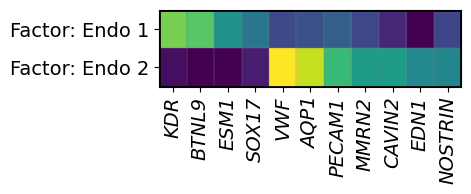

In [5]:
gene_list = gene_list = ['KDR', 'BTNL9', 'ESM1', 'SOX17'] + ['VWF', 'AQP1', 'PECAM1', 'MMRN2', 'CAVIN2', 'EDN1', 'NOSTRIN']

n_factors = 2
gene_set = gene_list
profile = basis_df.iloc[[36,40], :]
profile = profile[gene_set]
factor_names = ["Factor: Endo 1", "Factor: Endo 2"]

f = plt.figure(figsize=(3.9,1.))
ax = f.add_subplot(111)
# ax.set_ylabel('Factor', fontsize=14)
im = ax.imshow(profile, cmap='viridis', interpolation='nearest', aspect='auto')
plt.yticks(np.arange(n_factors), factor_names, rotation=0, fontsize=14)
plt.xticks(np.arange(len(gene_set)), gene_set, rotation=90, fontsize=14, style="italic")
# plt.title("Gene signature of factors", fontsize=15)
plt.vlines(x=np.arange(len(gene_set))-0.5, ymin=-0.5, ymax=n_factors-0.5, color="gray", linewidth=1.5, alpha=0.2)
plt.hlines(y=np.arange(n_factors)-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="gray", linewidth=1.5, alpha=0.2)
plt.vlines(x=-0.5, ymin=-0.5, ymax=n_factors-0.5, color="k", linewidth=2, alpha=1)
plt.vlines(x=len(gene_set)-0.5, ymin=-0.5, ymax=n_factors-0.5, color="k", linewidth=2, alpha=1)
plt.hlines(y=-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="k", linewidth=2, alpha=1)
plt.hlines(y=n_factors-0.5, xmin=-0.5, xmax=len(gene_set)-0.5, color="k", linewidth=2, alpha=1)

plt.show()

### Gene expression pattern among endothelial factor-related cells

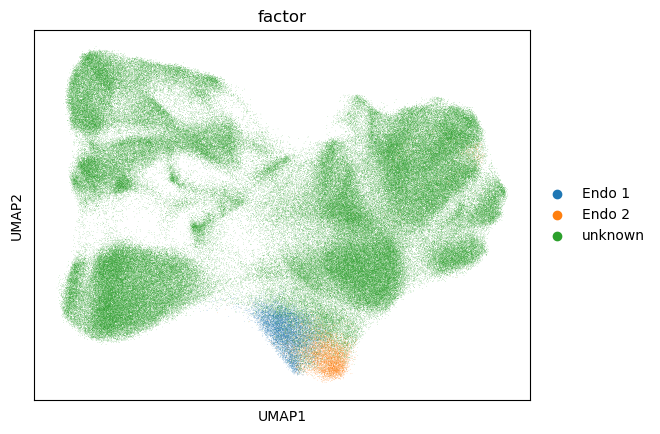

In [6]:
adata.obs["factor"] = "unknown"

factor_prop = adata.obs["Proportion of spatial factor 37"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Endo 1"

factor_prop = adata.obs["Proportion of spatial factor 41"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Endo 2"

sc.pl.umap(adata, color="factor")

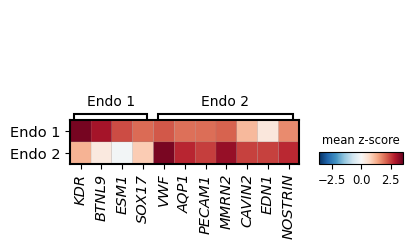

In [7]:
adata_raw = sc.read_h5ad("/gpfs/gibbs/pi/zhao/jz874/project/jiazhao/inspire_revision/tumor_microenvironment/Xenium_BC/adata_raw_umap.h5ad")
adata_raw.obs["Endo"] = adata.obs["factor"].values.astype(str)
adata_1 = adata_raw[adata_raw.obs["Endo"] == "Endo 1", :].copy()
adata_2 = adata_raw[adata_raw.obs["Endo"] == "Endo 2", :].copy()
adata_myoepi = ad.concat([adata_1, adata_2])

marker_genes_dict = {"Endo 1": ['KDR', 'BTNL9', 'ESM1', 'SOX17'],
                     "Endo 2": ['VWF', 'AQP1', 'PECAM1', 'MMRN2', 'CAVIN2', 'EDN1', 'NOSTRIN']}

fig, ax = plt.subplots(figsize=(4.3,2))
mt = sc.pl.matrixplot(
    adata_myoepi,
    marker_genes_dict,
    "Endo",
    dendrogram=False,
    colorbar_title="mean z-score",
    # layer="scaled",
    cmap="RdBu_r",
    # cmap="Reds",
    vmax=3.6,
    vmin=-3.6,
    # vmin=0.
    var_group_rotation=0,
    ax=ax,
    show=False
)
ax_main = mt['mainplot_ax']
for l in ax_main.get_xticklabels():
    l.set_style('italic')
    l.set_fontsize(10.5)
for l in ax_main.get_yticklabels():
    l.set_fontsize(10.5)

plt.show()

### Correlation analysis of spatial factors and their associated gene expression profiles

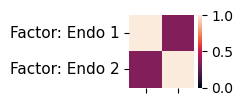

In [8]:
factor_myoepi = np.array(adata.obs[["Proportion of spatial factor 37", "Proportion of spatial factor 41"]].values)
corr_factor = np.corrcoef(factor_myoepi.T)

import seaborn as sns

plt.figure(figsize = (2*0.8*0.65,1.6*0.9*0.65))
sns.heatmap(corr_factor, vmin=0., vmax=1.)
plt.yticks(ticks=[0.5,1.5], labels=["Factor: Endo 1", "Factor: Endo 2"], rotation=0, fontsize=11)
plt.xticks(ticks=[0.5,1.5], labels=["", ""])

plt.show()

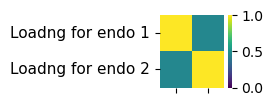

In [9]:
import seaborn as sns
corr_loading = basis_df.iloc[[36,40], :].T.corr()

import seaborn as sns

plt.figure(figsize = (2*0.8*0.65,1.6*0.9*0.65))
sns.heatmap(corr_loading, vmin=0., vmax=1., cmap="viridis")
plt.yticks(ticks=[0.5,1.5], labels=["Loadng for endo 1", "Loadng for endo 2"], rotation=0, fontsize=11)
plt.xticks(ticks=[0.5,1.5], labels=["", ""])

plt.show()

### Construction of the spatial map for endothelial factor-related cells

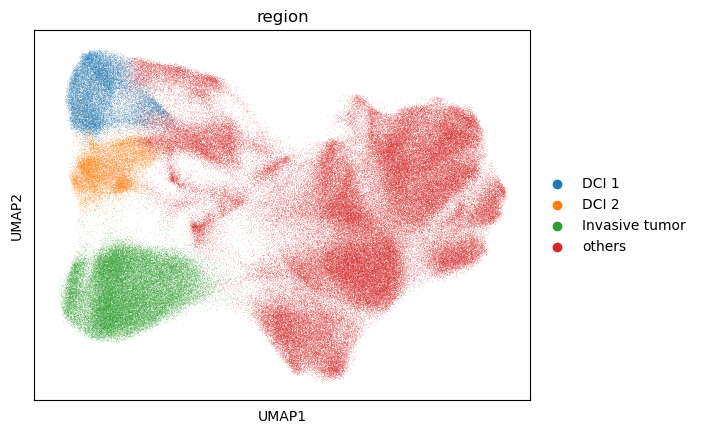

In [10]:
adata = sc.read_h5ad(res_path + "/adata_inspire_with_louvain.h5ad")
adata.obsm["factors"] = np.array(adata.obs[["Proportion of spatial factor "+str(j+1) for j in range(50)]].values)

adata.obs["region"] = "others"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "2"] = "DCI 1"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "8"] = "DCI 2"
adata.obs["region"][adata.obs["louvain"].values.astype(str) == "0"] = "Invasive tumor"

sc.pl.umap(adata, color="region")

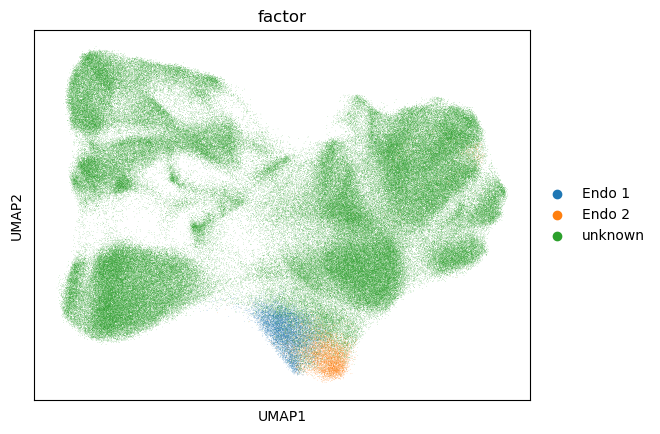

In [11]:
adata.obs["factor"] = "unknown"

factor_prop = adata.obs["Proportion of spatial factor 37"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Endo 1"

factor_prop = adata.obs["Proportion of spatial factor 41"].values
factor_prop_max = np.max(adata.obsm["factors"], axis=1)
adata.obs["factor"][factor_prop >= factor_prop_max] = "Endo 2"

sc.pl.umap(adata, color="factor")

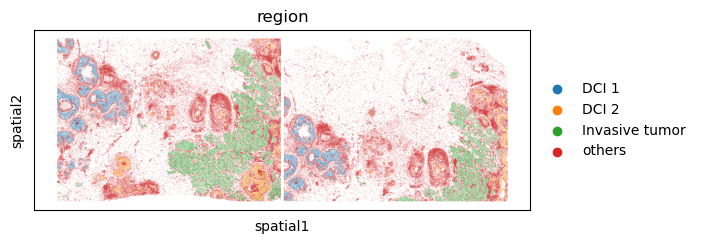

In [12]:
sc.pl.spatial(adata, color="region", spot_size=10.)

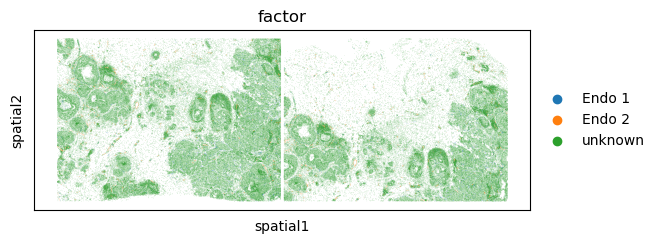

In [13]:
sc.pl.spatial(adata, color="factor", spot_size=10.)

### Spatial colocalization analysis between endothelial factor-related cells and distinct tumor subtypes

In [14]:
### calculate co-localize
adata_rep1 = adata[adata.obs["slice_label"].values.astype(str) == "0", :].copy()
adata_rep2 = adata[adata.obs["slice_label"].values.astype(str) == "1", :].copy()

loc_rep1 = adata_rep1.obsm["spatial"]
loc_rep2 = adata_rep2.obsm["spatial"]

In [15]:
coloc_val = np.zeros((2,3)) #factor by tumor type


k_nn = 50
adata_tmp = adata_rep1.copy()
loc_tmp = loc_rep1.copy()


tumor_type = "DCI 1"
cell_type = "Endo 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Endo 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Endo 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,2] = count / len(idx_tumor)


tumor_type = "DCI 1"
cell_type = "Endo 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Endo 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Endo 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,2] = count / len(idx_tumor)

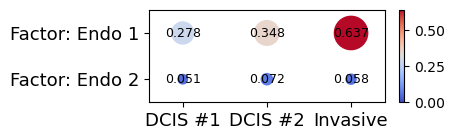

In [16]:
f, ax = plt.subplots(figsize=(3.8, 1.2))
n_topic = 3

for j in range(2):
    y = coloc_val[j, :]
    plt.scatter(np.arange(n_topic), (np.ones(n_topic)*(1-j)), c=y, s=y*900, cmap="coolwarm", vmin=0.0, vmax=0.64)
    y = ["%.3f" % y[t] for t in range(len(y))]
    for t in range(len(y)):
        plt.text(np.arange(n_topic)[t], (np.ones(n_topic)*(1-j))[t], [str(s) for s in list(y)][t], ha='center', va='center', fontsize=9)

plt.xticks(np.arange(3), ["DCIS #1", "DCIS #2", "Invasive"], rotation=0, fontsize=13)
plt.yticks(1-np.arange(2), ["Factor: Endo 1", "Factor: Endo 2"], rotation=0, fontsize=13)
plt.ylim(-0.5, 1.5)
plt.xlim(-0.4, 2.4)
plt.colorbar()

plt.show()

In [17]:
coloc_val = np.zeros((2,3)) #factor by tumor type


k_nn = 50
adata_tmp = adata_rep2.copy()
loc_tmp = loc_rep2.copy()


tumor_type = "DCI 1"
cell_type = "Endo 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Endo 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Endo 1"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[0,2] = count / len(idx_tumor)


tumor_type = "DCI 1"
cell_type = "Endo 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,0] = count / len(idx_tumor)


tumor_type = "DCI 2"
cell_type = "Endo 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,1] = count / len(idx_tumor)


tumor_type = "Invasive tumor"
cell_type = "Endo 2"
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(loc_tmp)
distances, indices = nbrs.kneighbors(loc_tmp)
idx_tumor = np.where(adata_tmp.obs["region"] == tumor_type)[0]
indices = indices[idx_tumor, :]
count = 0
for j in range(indices.shape[0]):
    ct_vec = adata_tmp.obs["factor"][indices[j,:]].values.astype(str)
    if np.sum(ct_vec == cell_type) > 0:
        count = count + 1
coloc_val[1,2] = count / len(idx_tumor)

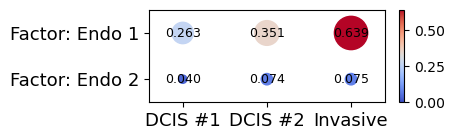

In [18]:
f, ax = plt.subplots(figsize=(3.8, 1.2))
n_topic = 3

for j in range(2):
    y = coloc_val[j, :]
    plt.scatter(np.arange(n_topic), (np.ones(n_topic)*(1-j)), c=y, s=y*900, cmap="coolwarm", vmin=0.0, vmax=0.64)
    y = ["%.3f" % y[t] for t in range(len(y))]
    for t in range(len(y)):
        plt.text(np.arange(n_topic)[t], (np.ones(n_topic)*(1-j))[t], [str(s) for s in list(y)][t], ha='center', va='center', fontsize=9)

plt.xticks(np.arange(3), ["DCIS #1", "DCIS #2", "Invasive"], rotation=0, fontsize=13)
plt.yticks(1-np.arange(2), ["Factor: Endo 1", "Factor: Endo 2"], rotation=0, fontsize=13)
plt.ylim(-0.5, 1.5)
plt.xlim(-0.4, 2.4)
plt.colorbar()

plt.show()